#  Обнаружение объектов

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* https://pytorch.org/tutorials/intermediate/torchvision_tutorial.html
* https://pyimagesearch.com/2021/11/01/training-an-object-detector-from-scratch-in-pytorch/
* https://pyimagesearch.com/2021/08/02/pytorch-object-detection-with-pre-trained-networks/

## Задачи для совместного разбора

1\. Рассмотрите простейшую архитектуру для решения задачи object detection и процесс настройки модели.

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Напишите функцию `parse_xml`, которая читает xml-файл с разметкой изображения из архива `animals.zip` и возвращает словарь, содержащий три ключа:
```
{
        "raw": # словарь с ключами xmin, ymin, xmax, ymax
        "scaled": # словарь с ключами xmin, ymin, xmax, ymax
        "obj_name": # строка
}
```
В этом словаре `row` - абсолютные значения координат вершин bounding box, а `scaled` - относительные (нормированные на ширину и высоту изображения). Примените функцию к файлу `cat.0.xml` и выведите результат на экран.


- [ ] Проверено на семинаре

In [ ]:
import xml.etree.ElementTree as ET
from torch.utils.data import Dataset
from PIL import Image
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import random_split, DataLoader
from torchvision.models import resnet50, ResNet50_Weights
import torch.optim as optim
from tqdm import tqdm

In [ ]:
def parse_xml(xml_path: str):
    # Парсим XML-файл
    tree = ET.parse(xml_path)
    root = tree.getroot()

    width = int(root.find("size/width").text)
    height = int(root.find("size/height").text)

    obj = root.find("object")
    obj_name = obj.find("name").text

    bnd = obj.find("bndbox")
    xmin = float(bnd.find("xmin").text)
    ymin = float(bnd.find("ymin").text)
    xmax = float(bnd.find("xmax").text)
    ymax = float(bnd.find("ymax").text)

    raw = {
        "xmin": xmin,
        "ymin": ymin,
        "xmax": xmax,
        "ymax": ymax,
    }

    scaled = {
        "xmin": xmin / width,
        "ymin": ymin / height,
        "xmax": xmax / width,
        "ymax": ymax / height,
    }

    result = {
        "raw": raw,
        "scaled": scaled,
        "obj_name": obj_name,
    }

    return result

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving animals.zip to animals.zip


In [ ]:
!unzip animals.zip -d /content/animals

In [ ]:
res = parse_xml("/content/animals/Asirra: cat vs dogs/cat.0.xml")
print(res)

{'raw': {'xmin': 126, 'ymin': 83, 'xmax': 354, 'ymax': 243}, 'scaled': {'xmin': 0.252, 'ymin': 0.22192513368983957, 'xmax': 0.708, 'ymax': 0.6497326203208557}, 'obj_name': 'cat'}


<p class="task" id="2"></p>

2\. Опишите датасет `AnimalDetectionDataset` на основе архива `animals.zip`. Реализуйте `__getitem__` таким образом, чтобы он возвращал три элемента: тензор с изображением, словарь с координатами bounding box и метку объекта. Предусмотрите возможность передавать извне при создании датасета набор преобразований для изображений, преобразование для метки объекта (для кодирования) и флаг, показывающий, нужно ли возвращать исходные или нормированные координаты bounding box.

- [ ] Проверено на семинаре

In [ ]:
class AnimalDetectionDataset(Dataset):
    def __init__(self, root, transforms=None, target_transform=None, return_scaled=True):
        self.root = root
        self.transforms = transforms
        self.target_transform = target_transform
        self.return_scaled = return_scaled

        self.samples = []
        for fname in os.listdir(root):
            if fname.endswith('.jpg'):
                img_path = os.path.join(root, fname)
                xml_path = img_path[:-4] + '.xml'
                if os.path.exists(xml_path):
                    self.samples.append((img_path, xml_path))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, xml_path = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transforms:
            image = self.transforms(image)
        obj = parse_xml(xml_path)
        bbox_key = "scaled" if self.return_scaled else "raw"
        bbox = obj[bbox_key]
        label = obj["obj_name"]
        if self.target_transform:
            label = self.target_transform(label)
        return image, bbox, label


<p class="task" id="3"></p>

3\. Создайте объект класса `AnimalDetectionDataset` без применения преобразований и со значением `return_scaled=False`. Напишите функцию `show_image_with_bounding_box` для визуализации изображения с добавлением на него bounding box и подписи объекта. Продемонстрируйте работу функцию на изображении собаки и кошки.

- [ ] Проверено на семинаре

In [ ]:
dataset = AnimalDetectionDataset(root='/content/animals/Asirra: cat vs dogs',
                                transforms=None,
                                target_transform=None,
                                return_scaled=False)

In [ ]:
def show_image_with_bounding_box(image, bbox, label):
    if hasattr(image, 'permute'):  # torch.Tensor: [C, H, W] -> [H, W, C]
        image_np = image.permute(1, 2, 0).cpu().numpy()
    else:
        image_np = np.array(image)

    fig, ax = plt.subplots(1)
    ax.imshow(image_np)

    xmin, ymin, xmax, ymax = bbox['xmin'], bbox['ymin'], bbox['xmax'], bbox['ymax']
    width, height = xmax - xmin, ymax - ymin

    rect = patches.Rectangle((xmin, ymin), width, height, linewidth=2, edgecolor='r', facecolor='none')
    ax.add_patch(rect)

    ax.text(xmin, ymin-5, label, color='red', fontsize=12, weight='bold', bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

    plt.axis('off')
    plt.show()


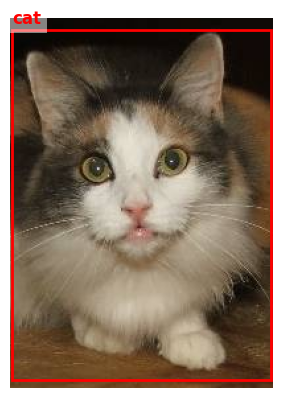

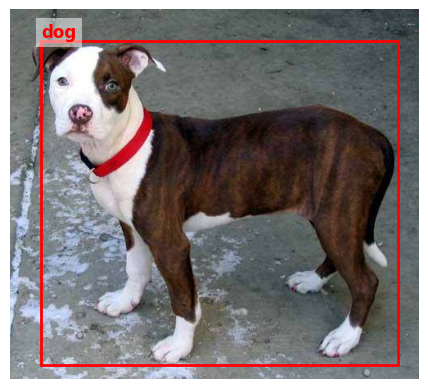

In [ ]:
for i in range(len(dataset)):
    _, _, label = dataset[i]
    if label == 'cat':
        idx_cat = i
        break

for i in range(len(dataset)):
    _, _, label = dataset[i]
    if label == 'dog':
        idx_dog = i
        break

image, bbox, label = dataset[idx_cat]
show_image_with_bounding_box(image, bbox, label)

image, bbox, label = dataset[idx_dog]
show_image_with_bounding_box(image, bbox, label)


<p class="task" id="4"></p>

4\. Напишите модель для решения задачи выделения объектов. Реализуйте двухголовую сеть, одна голова которой предсказывает метку объекта (задача классификации), а вторая голова предсказывает 4 координаты вершин bounding box (задача регрессии). В качестве backbone используйте модель resnet50 из пакета `torchvision`.

- [ ] Проверено на семинаре

In [ ]:
class ObjectDetectionNet(nn.Module):
  def __init__(self, num_classes):
    super().__init__()
    resnet = resnet50(weights = ResNet50_Weights.DEFAULT)
    self.backbone = nn.Sequential(*list(resnet.children())[:-1])
    self.class_head = nn.Linear(2048, num_classes)
    self.box_head = nn.Linear(2048, 4)

  def forward(self, x):
    featur = self.backbone(x)
    featur = torch.flatten(featur, 1)
    class_logits = self.class_head(featur)
    box_preds = self.box_head(featur)
    return class_logits, box_preds

<p class="task" id="5"></p>

5\. Разбейте набор данных на обучающее и валидационное множество. Обучите модель, описанную в задаче 4. При создании датасета не забудьте указать преобразования, соответствующие модели ResNet.

Используйте сумму MSELoss (для расчета ошибки на задаче регрессии) и CrossEntropyLoss (для расчета ошибки на задачи классификации) для настройки весов модели. Для ускорения процесса обучения слои backbone можно заморозить. Во время обучения выводите на экран значения функции потерь на обучающем и валидационном множестве. Используя обученную модель, получите предсказания для изображения кошки и собаки и отрисуйте их. Выполните процедуру, обратную нормализации, чтобы корректно отобразить фотографии.

- [ ] Проверено на семинаре

In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
resnet_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

label_to_idx = {'cat': 0, 'dog': 1}

def encode_label(label):
    return label_to_idx[label]

dataset = AnimalDetectionDataset(
    root= '/content/animals/Asirra: cat vs dogs',
    transforms=resnet_transforms,
    target_transform=encode_label,
    return_scaled=True
)


In [ ]:
val_len = int(0.2 * len(dataset))
train_len = len(dataset) - val_len
train_dataset, val_dataset = random_split(dataset, [train_len, val_len])

In [ ]:
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
num_classes = 2
model = ObjectDetectionNet(num_classes).to(device)

for p in model.backbone.parameters():
    p.requires_grad = False

In [ ]:
criterion_class = nn.CrossEntropyLoss()
criterion_bbox = nn.MSELoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)


In [ ]:
num_epochs = 10
for epoch in range(num_epochs):

    model.train()
    train_loss = 0.0
    for images, bboxes, labels in tqdm(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        bboxes_tensor = torch.stack([
            bboxes['xmin'].float(),
            bboxes['ymin'].float(),
            bboxes['xmax'].float(),
            bboxes['ymax'].float()
        ], dim=1).to(device)

        optimizer.zero_grad()
        out_class, out_bbox = model(images)
        loss_class = criterion_class(out_class, labels)
        loss_bbox = criterion_bbox(out_bbox, bboxes_tensor)
        loss = loss_class + loss_bbox
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    print(f"Epoch {epoch+1} TRAIN LOSS: {train_loss/len(train_loader):.4f}")

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, bboxes, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            bboxes_tensor = torch.stack([
                bboxes['xmin'].float(),
                bboxes['ymin'].float(),
                bboxes['xmax'].float(),
                bboxes['ymax'].float()
            ], dim=1).to(device)

            out_class, out_bbox = model(images)
            loss_class = criterion_class(out_class, labels)
            loss_bbox = criterion_bbox(out_bbox, bboxes_tensor)
            loss = loss_class + loss_bbox
            val_loss += loss.item()
    print(f"Epoch {epoch+1} VAL LOSS: {val_loss/len(val_loader):.4f}")


100%|██████████| 28/28 [00:08<00:00,  3.45it/s]


Epoch 1 TRAIN LOSS: 0.4751
Epoch 1 VAL LOSS: 0.2099


100%|██████████| 28/28 [00:05<00:00,  4.95it/s]


Epoch 2 TRAIN LOSS: 0.1808
Epoch 2 VAL LOSS: 0.1392


100%|██████████| 28/28 [00:06<00:00,  4.41it/s]


...

Epoch 8 TRAIN LOSS: 0.0646
Epoch 8 VAL LOSS: 0.0836


100%|██████████| 28/28 [00:06<00:00,  4.62it/s]


Epoch 9 TRAIN LOSS: 0.0477
Epoch 9 VAL LOSS: 0.0859


100%|██████████| 28/28 [00:05<00:00,  4.85it/s]


Epoch 10 TRAIN LOSS: 0.0485
Epoch 10 VAL LOSS: 0.0789


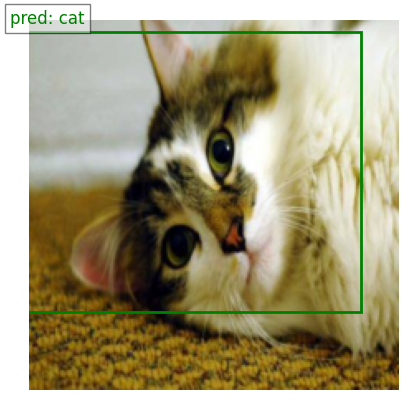

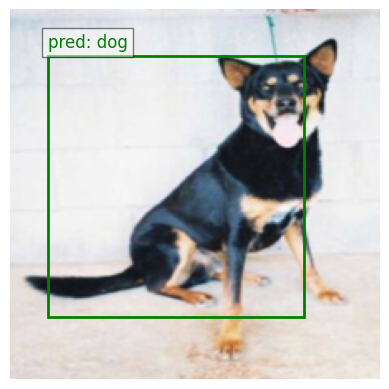

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def inv_normalize(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    tensor = tensor.cpu().numpy().transpose(1,2,0)
    return np.clip(std * tensor + mean, 0, 1)

model.eval()
def show_pred(dataset, idx):
    image, bbox_true, label = dataset[idx]
    img_input = image.unsqueeze(0).to(device)
    cls_pred, bbox_pred = model(img_input)
    label_pred = cls_pred.argmax(1).item()
    bbox_pred = bbox_pred.detach().cpu().numpy()[0]
    xmin = bbox_pred[0] * 224
    ymin = bbox_pred[1] * 224
    xmax = bbox_pred[2] * 224
    ymax = bbox_pred[3] * 224
    img_disp = inv_normalize(image)
    fig, ax = plt.subplots(1)
    ax.imshow(img_disp)
    rect = patches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin, linewidth=2, edgecolor='g', facecolor='none')
    ax.add_patch(rect)
    ax.text(xmin, ymin-5, f"pred: {'cat' if label_pred==0 else 'dog'}", color='g', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))
    plt.axis('off')
    plt.show()

idx_cat = next(i for i in range(len(val_dataset)) if val_dataset[i][2]==0)
idx_dog = next(i for i in range(len(val_dataset)) if val_dataset[i][2]==1)
show_pred(val_dataset, idx_cat)
show_pred(val_dataset, idx_dog)


<p class="task" id="6"></p>

6\. Найдите в сети несколько изображений котов и собак. Используя любой инструмент для разметки (например, [CVAT](https://www.cvat.ai/)), выделите котов и собак на изображениях. Вставьте скриншот экспортированного файла с разметкой. Используя полученные изображения, визуализируйте разметку и bounding boxes, полученные при помощи модели.

- [ ] Проверено на семинаре

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving data.zip to data.zip


In [ ]:
!unzip data.zip -d /content/data_data

Archive:  data.zip
 extracting: /content/data_data/labelmap.txt  
 extracting: /content/data_data/ImageSets/Main/default.txt  
 extracting: /content/data_data/Annotations/photo_2025-11-18 21.47.39.xml  
 extracting: /content/data_data/Annotations/photo_2025-11-18 21.48.01.xml  
 extracting: /content/data_data/Annotations/photo_2025-11-18 22.48.53.xml  
 extracting: /content/data_data/Annotations/photo_2025-11-18 23.03.52.xml  
 extracting: /content/data_data/Annotations/photo_2025-11-18 22.37.54.xml  
 extracting: /content/data_data/Annotations/photo_2025-11-18 22.48.56.xml  
 extracting: /content/data_data/Annotations/photo_2025-11-18 22.37.38.xml  
 extracting: /content/data_data/Annotations/photo_2025-11-18 21.47.16.xml  


In [ ]:
JPEG_dir = "/content/data_data"
ANN_dir = '/content/data_data/Annotations'

In [ ]:
label_map = {'cat': 0, 'dog': 1}

In [ ]:
def show_manual_and_model_bbox(image_path, xml_path):
    img_raw = Image.open(image_path).convert('RGB')
    ann = parse_xml(xml_path)

    xmin = ann["raw"]["xmin"]
    ymin = ann["raw"]["ymin"]
    xmax = ann["raw"]["xmax"]
    ymax = ann["raw"]["ymax"]
    gt_label = ann["obj_name"]

    img_for_model = resnet_transforms(img_raw).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        class_pred, bbox_pred = model(img_for_model)
        label_pred = class_pred.argmax(1).item()
        bbox_pred = bbox_pred.squeeze().cpu().numpy()
    xmin_p = bbox_pred[0] * 224
    ymin_p = bbox_pred[1] * 224
    xmax_p = bbox_pred[2] * 224
    ymax_p = bbox_pred[3] * 224

    orig_w, orig_h = img_raw.size
    scale_x = 224 / orig_w
    scale_y = 224 / orig_h
    xmin_s, xmax_s = xmin * scale_x, xmax * scale_x
    ymin_s, ymax_s = ymin * scale_y, ymax * scale_y

    img_for_plot = img_raw.resize((224, 224))
    fig, ax = plt.subplots(1)
    ax.imshow(np.array(img_for_plot))

    ax.add_patch(
        patches.Rectangle(
            (xmin_s, ymin_s), xmax_s-xmin_s, ymax_s-ymin_s,
            edgecolor='r', linewidth=2, facecolor='none'
        )
    )
    ax.text(
        xmin_s, ymin_s-8, gt_label,
        color='r', fontsize=12,
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.6)
    )

    pred_class = [k for k,v in label_map.items() if v==label_pred][0]
    ax.add_patch(
        patches.Rectangle(
            (xmin_p, ymin_p), xmax_p-xmin_p, ymax_p-ymin_p,
            edgecolor='g', linewidth=3, facecolor='none'
        )
    )
    ax.text(
        xmin_p, ymin_p-20, f"pred: {pred_class}",
        color='g', fontsize=12,
        bbox=dict(facecolor='white', linewidth=3, edgecolor='none')
    )
    plt.axis('off')
    plt.show()

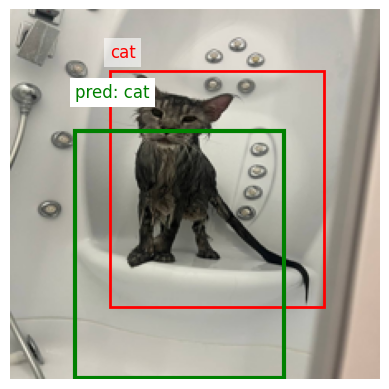

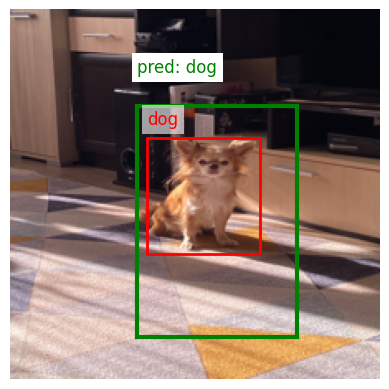

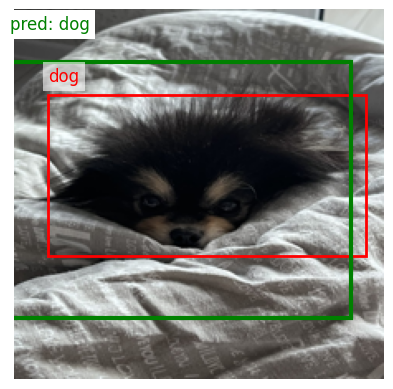

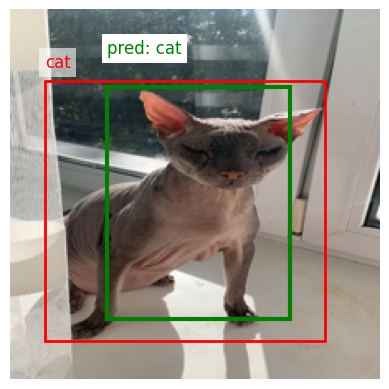

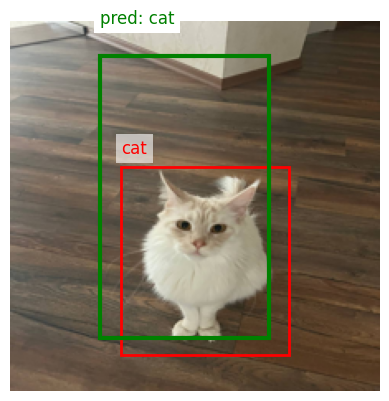

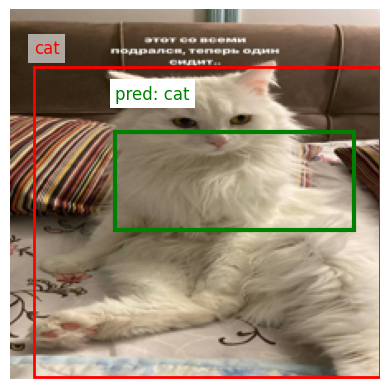

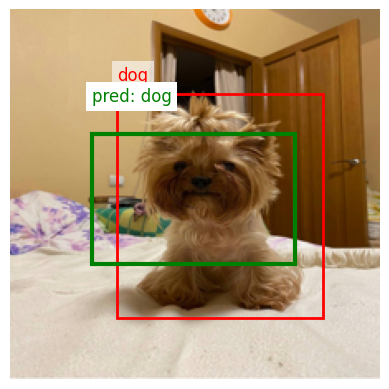

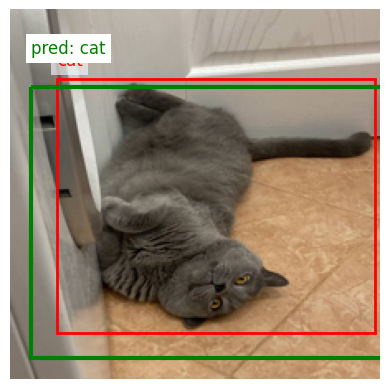

In [ ]:
images = sorted(os.listdir(JPEG_dir))
xmls = sorted(os.listdir(ANN_dir))
for img_name in images:
    base = os.path.splitext(img_name)[0]
    xml_path = os.path.join(ANN_dir, base + ".xml")
    img_path = os.path.join(JPEG_dir, img_name)
    if os.path.exists(xml_path):
        show_manual_and_model_bbox(img_path, xml_path)